In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# The exact path to your BASE_MODEL folder
TARGET_PATH = '/content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/new-audio.zip'

Extracted folder already exists at: /content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/extracted_dataset. Skipping unzip step!

Starting audio feature extraction from: /content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/extracted_dataset
Processing folder: notb
Processing folder: tb
Manifest index sheet updated at:
 -> /content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/audio_dataset_manifest.csv
Features matrices mapped: (1400, 128, 94, 1), Target labels mapped: (1400,)
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.6777 - loss: 0.7693 - precision: 0.6623 - recall: 0.7250 - val_accuracy: 0.5679 - val_loss: 0.6756 - val_precision: 0.5503 - val_recall: 0.7429
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8036 - loss: 0.4659 - precision: 0.7787 - recall: 0.8482 - val_accuracy: 0.6786 - val_loss: 0.6255 - val_precision: 0.9808 - val_recall: 0.3643
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8205 -


=== Test Evaluation Summary ===
Accuracy:  97.14%
Recall:    96.43%
Precision: 97.83%

Model architecture output successfully saved to Google Drive:
 -> /content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/tb_cough_base_model.h5


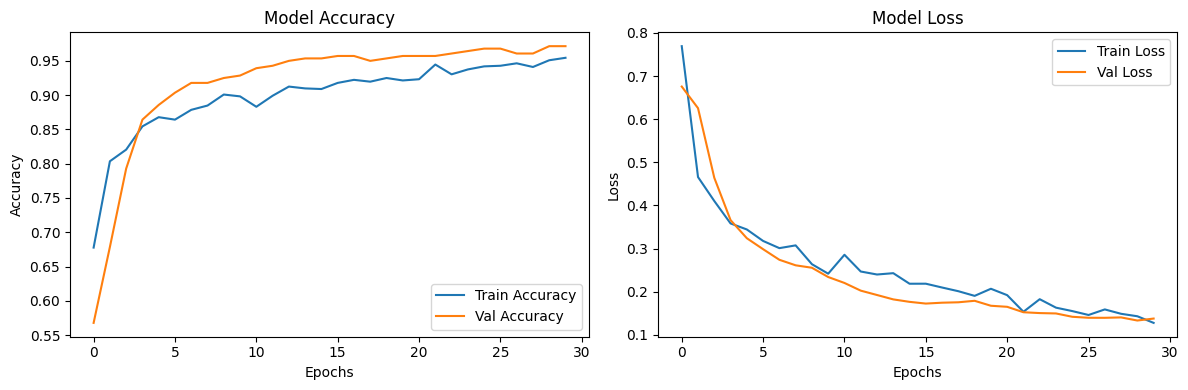

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION & PERMANENT PATHS
# ==========================================
TARGET_PATH = '/content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/'
ZIP_FILE_NAME = "new-audio.zip"

# The dataset will now extract and live permanently inside your Google Drive folder
EXTRACT_FOLDER_NAME = "extracted_dataset"
PERMANENT_EXTRACT_PATH = os.path.join(TARGET_PATH, EXTRACT_FOLDER_NAME)

CLASSES = ["notb", "tb"]
SR = 16000
DURATION = 3
AUDIO_LENGTH = SR * DURATION
N_MELS = 128

# ==========================================
# 2. PERMANENT ZIP EXTRACTION (RUNS ONCE)
# ==========================================
full_zip_path = os.path.join(TARGET_PATH, ZIP_FILE_NAME)

# Check if it has already been extracted in a previous session
if not os.path.exists(PERMANENT_EXTRACT_PATH):
    if not os.path.exists(full_zip_path):
        raise FileNotFoundError(f"Could not find the zip file at: {full_zip_path}")

    print(f"Extracting {ZIP_FILE_NAME} permanently into Google Drive folder...")
    with zipfile.ZipFile(full_zip_path, 'r') as zip_ref:
        zip_ref.extractall(PERMANENT_EXTRACT_PATH)
    print("Permanent extraction complete.")
else:
    print(f"Extracted folder already exists at: {PERMANENT_EXTRACT_PATH}. Skipping unzip step!")

# ==========================================
# 3. FEATURE EXTRACTION & CSV GENERATION
# ==========================================
def extract_features_and_log(dataset_path):
    X = []
    y = []
    manifest_data = []

    print(f"\nStarting audio feature extraction from: {dataset_path}")
    for label_idx, class_name in enumerate(CLASSES):
        # Locate class subfolders inside the permanent extraction path
        class_folder = None
        for root, dirs, files in os.walk(dataset_path):
            if class_name in dirs:
                class_folder = os.path.join(root, class_name)
                break

        if class_folder is None or not os.path.exists(class_folder):
            print(f"Warning: Could not locate directory named '{class_name}' inside the extracted folder.")
            continue

        print(f"Processing folder: {class_name}")
        for file_name in os.listdir(class_folder):
            if file_name.lower().endswith(('.wav', '.mp3', '.m4a', '.3gp')):
                file_path = os.path.join(class_folder, file_name)

                try:
                    # Load from permanent drive path
                    audio, sr = librosa.load(file_path, sr=SR)

                    if len(audio) < AUDIO_LENGTH:
                        audio = np.pad(audio, (0, AUDIO_LENGTH - len(audio)), 'constant')
                    else:
                        audio = audio[:AUDIO_LENGTH]

                    mel_spec = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS)
                    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

                    X.append(log_mel_spec)
                    y.append(label_idx)

                    manifest_data.append({
                        "audio_id": os.path.splitext(file_name)[0],
                        "file_name": file_name,
                        "class_folder": class_name,
                        "tb_status_label": label_idx
                    })
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

    if manifest_data:
        df_manifest = pd.DataFrame(manifest_data)
        csv_save_path = os.path.join(TARGET_PATH, "audio_dataset_manifest.csv")
        df_manifest.to_csv(csv_save_path, index=False)
        print(f"Manifest index sheet updated at:\n -> {csv_save_path}")

    return np.array(X), np.array(y)

# Load features directly using the permanent drive dataset folder
X, y = extract_features_and_log(PERMANENT_EXTRACT_PATH)

if len(X) == 0:
    raise ValueError("No audio samples were loaded. Please verify the folder names are 'tb' and 'notb'.")

X = X[..., np.newaxis]
print(f"Features matrices mapped: {X.shape}, Target labels mapped: {y.shape}")

# ==========================================
# 4. TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ==========================================
# 5. BUILDING THE CNN MODEL
# ==========================================
input_shape = (X_train.shape[1], X_train.shape[2], 1)

model = models.Sequential([
    layers.Input(shape=input_shape),

    # Block 1 - Smaller filter count
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),  # Increased dropout

    # Block 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),  # Stronger dropout before flattening

    layers.Flatten(),
    layers.Dense(64, activation='relu'),  # Reduced from 128 to 64
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)
callbacks = [
    # Halts training if validation loss doesn't improve for 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Lowers learning rate if progress slows down
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
# ==========================================
# 6. TRAINING
# ==========================================
EPOCHS = 30
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1
)

# ==========================================
# 7. EVALUATION & MODEL STORAGE
# ==========================================
test_loss, test_acc, test_recall, test_precision = model.evaluate(X_test, y_test, verbose=0)
print("\n=== Test Evaluation Summary ===")
print(f"Accuracy:  {test_acc*100:.2f}%")
print(f"Recall:    {test_recall*100:.2f}%")
print(f"Precision: {test_precision*100:.2f}%")

output_model_path = os.path.join(TARGET_PATH, "tb_cough_base_model.h5")
model.save(output_model_path)
print(f"\nModel architecture output successfully saved to Google Drive:\n -> {output_model_path}")

# Create evaluation plots
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

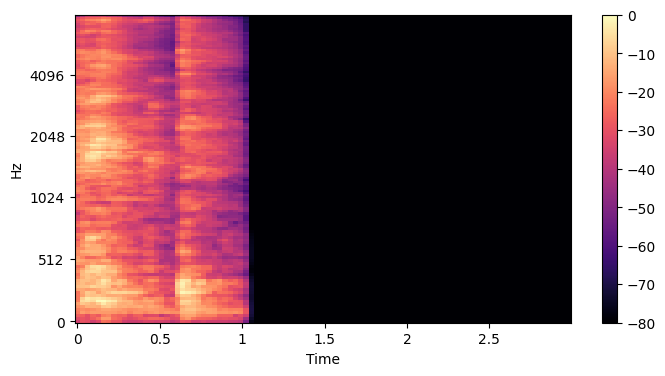

In [ ]:
plt.figure(figsize=(8,4))
librosa.display.specshow(
    X_train[0].squeeze(),
    sr=SR,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar()
plt.show()

In [ ]:
import os

print(os.listdir('/content/drive/Shareddrives'))

[]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading your trained TB Cough Base Model...


Model loaded successfully!
Please allow microphone access.


<IPython.core.display.Javascript object>

Recording completed.
 -> Detected RNN model. Structuring input for Sequential Timesteps...


/tmp/ipykernel_1025/190951484.py:146: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(TEMP_AUDIO, sr=SR)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



         LIVE COUGH PREDICTION SCORE
Result:           Tuberculosis Detected
Confidence Score: 76.98%


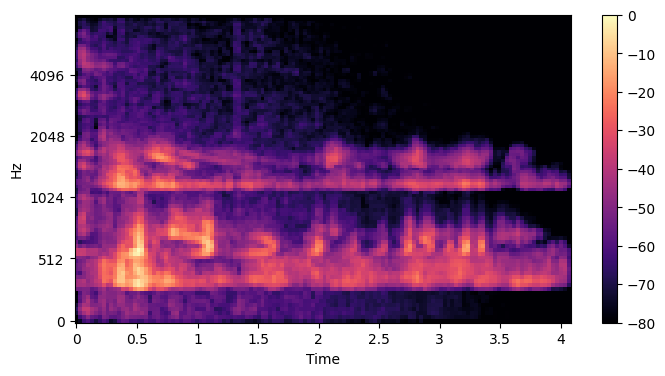

In [10]:
import os
import numpy as np
import librosa
import tensorflow as tf
from IPython.display import display, Javascript
from google.colab import output
import base64
from google.colab import drive

# ==========================================
# 0. MOUNT GOOGLE DRIVE
# ==========================================
drive.mount('/content/drive')

# ==========================================
# 1. CONFIGURATION & MODEL LOADING
# ==========================================

# CHANGE THIS PATH TO YOUR SHARED DRIVE
TARGET_PATH = '/content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/'

MODEL_PATH = os.path.join(TARGET_PATH, "tb_cough_base_model.h5")

SR = 16000
DURATION = 3
AUDIO_LENGTH = SR * DURATION
N_MELS = 128

CLASSES = [
    "No Tuberculosis (Healthy/Other Cough)",
    "Tuberculosis Detected"
]

# ==========================================
# LOAD TRAINED MODEL
# ==========================================

if os.path.exists(MODEL_PATH):
    print("Loading your trained TB Cough Base Model...")
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Model loaded successfully!")
else:
    raise FileNotFoundError(
        f"Could not find model at:\n{MODEL_PATH}"
    )

# ==========================================
# 2. JAVASCRIPT AUDIO RECORDER
# ==========================================

RECORD_JS = """
const sleep = time => new Promise(resolve => setTimeout(resolve, time));

const b2string = blob => new Promise(resolve => {
  const reader = new FileReader();
  reader.onloadend = () => resolve(reader.result);
  reader.readAsDataURL(blob);
});

async function recordAudio(duration_ms){

  const div=document.createElement('div');

  const button=document.createElement('button');

  button.textContent='🎤 Click to Record 3 Seconds';

  button.style.padding='15px';
  button.style.fontSize='18px';
  button.style.background='#0d6efd';
  button.style.color='white';
  button.style.border='none';
  button.style.borderRadius='6px';

  div.appendChild(button);

  document.body.appendChild(div);

  await new Promise(resolve=>button.onclick=resolve);

  button.textContent='Recording... Please cough';

  const stream=await navigator.mediaDevices.getUserMedia({audio:true});

  const recorder=new MediaRecorder(stream);

  const chunks=[];

  recorder.ondataavailable=e=>chunks.push(e.data);

  recorder.start();

  await sleep(duration_ms);

  recorder.stop();

  button.textContent='Processing...';

  await new Promise(resolve=>recorder.onstop=resolve);

  stream.getTracks().forEach(track=>track.stop());

  const blob=new Blob(chunks,{type:'audio/wav'});

  const base64data=await b2string(blob);

  div.remove();

  return base64data;
}
"""

# ==========================================
# RECORD FUNCTION
# ==========================================

def record_live_cough(filename="live_cough.wav", duration=3):

    print("Please allow microphone access.")

    display(Javascript(RECORD_JS))

    audio_data = output.eval_js(
        f"recordAudio({duration*1000})"
    )

    audio_bytes = base64.b64decode(audio_data.split(",")[1])

    with open(filename, "wb") as f:
        f.write(audio_bytes)

    print("Recording completed.")

# ==========================================
# LIVE PREDICTION
# ==========================================

# ==========================================
# UNIVERSAL LIVE PREDICTION (CNN & RNN AUTO-ADAPTIVE)
# ==========================================
try:
    TEMP_AUDIO = "live_cough.wav"
    record_live_cough(TEMP_AUDIO, DURATION)

    # 1. Load and pad/trim the live audio clip
    audio, sr = librosa.load(TEMP_AUDIO, sr=SR)
    if len(audio) < AUDIO_LENGTH:
        audio = np.pad(audio, (0, AUDIO_LENGTH-len(audio)), mode="constant")
    else:
        audio = audio[:AUDIO_LENGTH]

    # 2. Extract Log-Mel Spectrogram features
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS)
    mel = librosa.power_to_db(mel, ref=np.max)

    # 3. Dynamic Shape Checking
    # Inspects the expected input shape length from the loaded model
    expected_input_dims = len(model.input_shape)

    if expected_input_dims == 4:
        # It's a CNN model: Needs (1, 128, 94, 1)
        print(" -> Detected CNN model. Structuring input for 2D Convolutions...")
        sample = mel[np.newaxis, ..., np.newaxis]

    elif expected_input_dims == 3:
        # It's an RNN model: Needs (1, 94, 128)
        print(" -> Detected RNN model. Structuring input for Sequential Timesteps...")
        mel_rnn = np.transpose(mel, (1, 0))
        sample = mel_rnn[np.newaxis, ...]

    else:
        raise ValueError(f"Unexpected model input shape dimension count: {expected_input_dims}")

    # 4. Predict using whichever model is currently active
    probability = model.predict(sample, verbose=0)[0][0]

    if probability >= 0.5:
        prediction = CLASSES[1]
        confidence = probability
    else:
        prediction = CLASSES[0]
        confidence = 1 - probability

    print(f"\n========================================")
    print(f"         LIVE COUGH PREDICTION SCORE")
    print(f"========================================")
    print(f"Result:           {prediction}")
    print(f"Confidence Score: {confidence * 100:.2f}%")
    print(f"========================================")

except Exception as e:
    print(f"\nPrediction failed.")
    print(e)
    print("\nMake sure:")
    print("1. Google Drive is mounted.")
    print("2. The model exists in the Shared Drive.")
    print("3. You granted microphone permission.")

plt.figure(figsize=(8,4))
librosa.display.specshow(
    sample[0].squeeze(),
    sr=SR,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar()
plt.show()

In [11]:
# Check model architecture dimensions
if len(model.input_shape) == 4:
    print(f"🔥 CURRENT MODEL ACTIVE: CNN (Convolutional Neural Network)")
    print(f"   -> Expected Input Shape: {model.input_shape} (Batch, Mel Bands, Time Steps, Channels)")
elif len(model.input_shape) == 3:
    print(f"🔥 CURRENT MODEL ACTIVE: RNN / LSTM (Recurrent Neural Network)")
    print(f"   -> Expected Input Shape: {model.input_shape} (Batch, Time Steps, Mel Bands)")
else:
    print(f"❓ Unknown Model Structure. Shape length is: {len(model.input_shape)}")

🔥 CURRENT MODEL ACTIVE: RNN / LSTM (Recurrent Neural Network)
   -> Expected Input Shape: (None, 94, 128) (Batch, Time Steps, Mel Bands)


Extracted folder already exists at: /content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/extracted_dataset. Skipping unzip step!

Starting audio feature extraction from: /content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/extracted_dataset
Processing folder: notb
Processing folder: tb
Manifest index sheet updated at:
 -> /content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/audio_dataset_manifest.csv
Features matrices mapped: (1400, 128, 94, 1), Target labels mapped: (1400,)
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.4857 - loss: 0.9401 - precision: 0.4907 - recall: 0.7518 - val_accuracy: 0.5143 - val_loss: 0.6923 - val_precision: 1.0000 - val_recall: 0.0286 - learning_rate: 1.0000e-04
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5705 - loss: 0.7680 - precision: 0.5474 - recall: 0.8143 - val_accuracy: 0.5036 - val_loss: 0.6898 - val_precision: 0.5556 - val_recall: 0.0357 - learning_rate: 1.0000e-04
Epoch 3/30
35/35


=== Test Evaluation Summary ===
Accuracy:  77.14%
Recall:    86.43%
Precision: 72.89%

Model architecture output successfully saved to Google Drive:
 -> /content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/tb_cough_base_model.h5


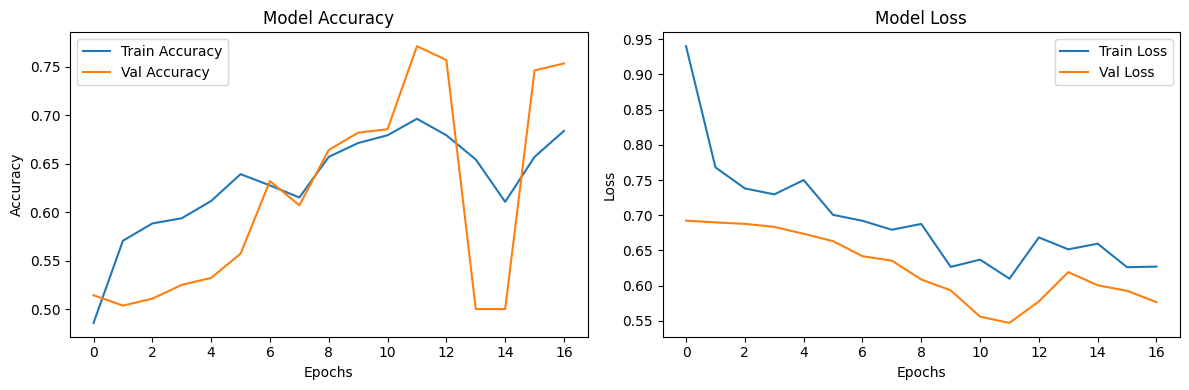

In [9]:
import os
import zipfile
import numpy as np
import pandas as pd
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION & PERMANENT PATHS
# ==========================================
TARGET_PATH = '/content/drive/MyDrive/FINAL YR PROJ/PROJ PHASE - 1/BASE_MODEL/'
ZIP_FILE_NAME = "new-audio.zip"

# The dataset will now extract and live permanently inside your Google Drive folder
EXTRACT_FOLDER_NAME = "extracted_dataset"
PERMANENT_EXTRACT_PATH = os.path.join(TARGET_PATH, EXTRACT_FOLDER_NAME)

CLASSES = ["notb", "tb"]
SR = 16000
DURATION = 3
AUDIO_LENGTH = SR * DURATION
N_MELS = 128

# ==========================================
# 2. PERMANENT ZIP EXTRACTION (RUNS ONCE)
# ==========================================
full_zip_path = os.path.join(TARGET_PATH, ZIP_FILE_NAME)

# Check if it has already been extracted in a previous session
if not os.path.exists(PERMANENT_EXTRACT_PATH):
    if not os.path.exists(full_zip_path):
        raise FileNotFoundError(f"Could not find the zip file at: {full_zip_path}")

    print(f"Extracting {ZIP_FILE_NAME} permanently into Google Drive folder...")
    with zipfile.ZipFile(full_zip_path, 'r') as zip_ref:
        zip_ref.extractall(PERMANENT_EXTRACT_PATH)
    print("Permanent extraction complete.")
else:
    print(f"Extracted folder already exists at: {PERMANENT_EXTRACT_PATH}. Skipping unzip step!")

# ==========================================
# 3. FEATURE EXTRACTION & CSV GENERATION
# ==========================================
def extract_features_and_log(dataset_path):
    X = []
    y = []
    manifest_data = []

    print(f"\nStarting audio feature extraction from: {dataset_path}")
    for label_idx, class_name in enumerate(CLASSES):
        # Locate class subfolders inside the permanent extraction path
        class_folder = None
        for root, dirs, files in os.walk(dataset_path):
            if class_name in dirs:
                class_folder = os.path.join(root, class_name)
                break

        if class_folder is None or not os.path.exists(class_folder):
            print(f"Warning: Could not locate directory named '{class_name}' inside the extracted folder.")
            continue

        print(f"Processing folder: {class_name}")
        for file_name in os.listdir(class_folder):
            if file_name.lower().endswith(('.wav', '.mp3', '.m4a', '.3gp')):
                file_path = os.path.join(class_folder, file_name)

                try:
                    # Load from permanent drive path
                    audio, sr = librosa.load(file_path, sr=SR)

                    if len(audio) < AUDIO_LENGTH:
                        audio = np.pad(audio, (0, AUDIO_LENGTH - len(audio)), 'constant')
                    else:
                        audio = audio[:AUDIO_LENGTH]

                    mel_spec = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS)
                    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

                    X.append(log_mel_spec)
                    y.append(label_idx)

                    manifest_data.append({
                        "audio_id": os.path.splitext(file_name)[0],
                        "file_name": file_name,
                        "class_folder": class_name,
                        "tb_status_label": label_idx
                    })
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

    if manifest_data:
        df_manifest = pd.DataFrame(manifest_data)
        csv_save_path = os.path.join(TARGET_PATH, "audio_dataset_manifest.csv")
        df_manifest.to_csv(csv_save_path, index=False)
        print(f"Manifest index sheet updated at:\n -> {csv_save_path}")

    return np.array(X), np.array(y)

# Load features directly using the permanent drive dataset folder
X, y = extract_features_and_log(PERMANENT_EXTRACT_PATH)

if len(X) == 0:
    raise ValueError("No audio samples were loaded. Please verify the folder names are 'tb' and 'notb'.")

X = X[..., np.newaxis]
print(f"Features matrices mapped: {X.shape}, Target labels mapped: {y.shape}")

# ==========================================
# 4. TRAIN-TEST SPLIT
# ==========================================
# If X has 4 dimensions (from np.newaxis), remove the last dimension for the RNN
if len(X.shape) == 4:
    X = np.squeeze(X, axis=-1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ==========================================
# 5. BUILDING THE RNN (LSTM) MODEL
# ==========================================
# LSTMs expect shape: (batch_size, time_steps, features).
# We transpose the last two dimensions to put Time Frames first as the sequential axis.
X_train_rnn = np.transpose(X_train, (0, 2, 1))
X_test_rnn = np.transpose(X_test, (0, 2, 1))

input_shape_rnn = (X_train_rnn.shape[1], X_train_rnn.shape[2]) # (94, 128)

model = models.Sequential([
    layers.Input(shape=input_shape_rnn),

    # Layer 1: Recurrent layer processing the temporal sequence
    layers.LSTM(64, return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Layer 2: Second recurrent layer to capture deeper patterns
    layers.LSTM(32, return_sequences=False),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Dense Classifier Head
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

# ==========================================
# 6. TRAINING
# ==========================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

EPOCHS = 30
BATCH_SIZE = 32

history = model.fit(
    X_train_rnn, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_rnn, y_test),
    callbacks=callbacks,
    verbose=1
)

# ==========================================
# 7. EVALUATION & MODEL STORAGE
# ==========================================
test_loss, test_acc, test_recall, test_precision = model.evaluate(X_test_rnn, y_test, verbose=0)
print("\n=== Test Evaluation Summary ===")
print(f"Accuracy:  {test_acc*100:.2f}%")
print(f"Recall:    {test_recall*100:.2f}%")
print(f"Precision: {test_precision*100:.2f}%")

output_model_path = os.path.join(TARGET_PATH, "tb_cough_base_model.h5")
model.save(output_model_path)
print(f"\nModel architecture output successfully saved to Google Drive:\n -> {output_model_path}")

# Create evaluation plots
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()